In [1]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [2]:
seed = 2724

### Import data

In [3]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [4]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Use SHAP to explain the model on test data

In [7]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

This will allow us to see which variables are most important to predicting the outcome.

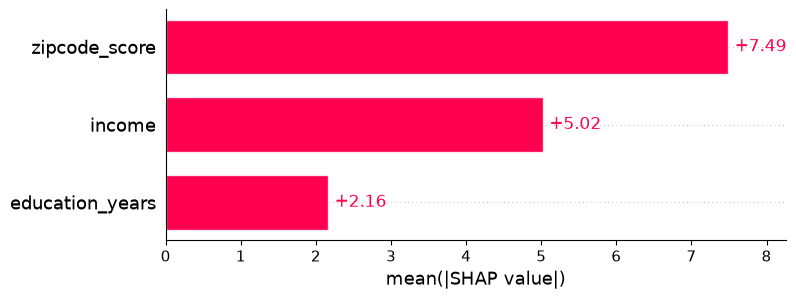

In [8]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [9]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [10]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

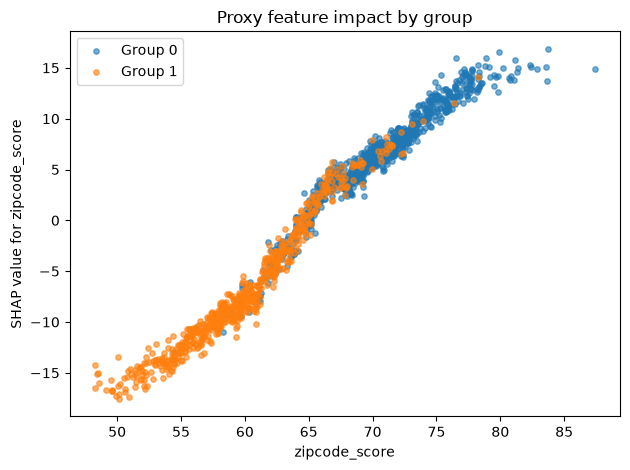

In [11]:
def plot_shap(var):
    # Show each group's contribution for this feature
    shap_var = shap_values[:, var].values
    groups = X_test_with_group["group"].values

    plt.figure()
    for group in sorted(np.unique(groups)):
        mask = groups == group
        plt.scatter(
            X_test.loc[mask, var],
            shap_var[mask],
            label=f"Group {group}",
            alpha=0.6,
            s=15
        )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for {var}")
    plt.title("Proxy feature impact by group")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

A SHAP value tells us how much one feature contributes to a particular prediction compared with the model's baseline prediction. A positive value pushes the prediction higher, and a negative value pushes it lower. Shapley values come from averaging a feature's contribution over different combinations of features. The SHAP values for all the features add up to the difference between the prediction and the baseline.

Reference: [SHAP documentation](https://shap.readthedocs.io/en/stable/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html).

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

No, I only used `income`, `education_years`, and `zipcode_score` to train the model. I added `group` to a copy of the test data afterward to compare the groups. However, leaving out `group` does not mean the model is free of bias, because another input could act as a proxy for it.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

In [12]:
# Compare predictions for the two groups on the test set
results = pd.DataFrame({
    "group": X_test_with_group["group"],
    "prediction": model.predict(X_test)
})
print(results.groupby("group")["prediction"].mean())
print("Correlation with group:", round(results["prediction"].corr(results["group"]), 3))

group
0    100.052599
1     87.238409
Name: prediction, dtype: float64
Correlation with group: -0.569


Yes. On the test set, the average prediction is about 100.05 for group 0 and 87.24 for group 1. The correlation between the prediction and `group` is about -0.57, so group 1 tends to receive lower predictions. The average SHAP contribution from `zipcode_score` is about +5.87 for group 0 and -6.86 for group 1, while the average income and education contributions are similar across groups. This suggests that ZIP code is acting as a proxy for `group`. It raises a bias concern, but I would need to know what the target means and compare the model's errors across groups before deciding whether the difference is unfair.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

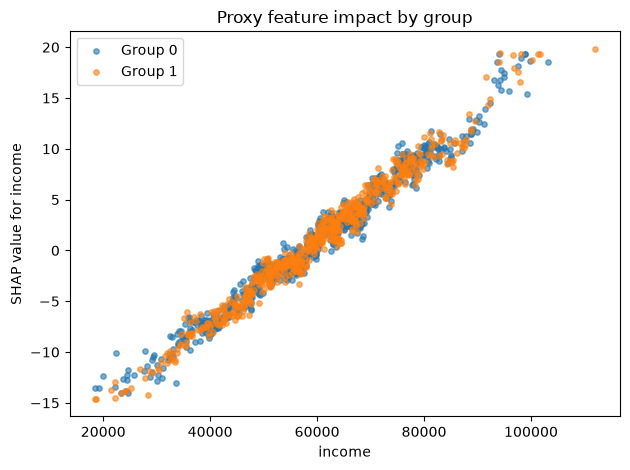

In [13]:
plot_shap("income")

In the income plot, the two groups overlap across the income range and follow almost the same upward trend: lower incomes generally lower the prediction, and higher incomes raise it. In the ZIP code plot, group 0 is more concentrated at higher `zipcode_score` values with positive SHAP contributions, while group 1 is more concentrated at lower scores with negative contributions. There is still some overlap, but ZIP code separates the groups much more clearly than income does. The average income SHAP values are close (about +1.09 for group 0 and +1.02 for group 1), unlike the ZIP code averages (+5.87 and -6.86). Income does not show the same proxy pattern in this test set.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

1. Where did the training data and target values come from? Could the target already reflect unfair decisions made in the past?
2. Does the model make larger errors or consistently overpredict or underpredict for one group compared with the other?
3. What happens to the predictions and the difference between groups if `zipcode_score` is removed and the model is retrained?
4. What is the model being used to predict, and how would a higher or lower prediction affect the people in each group?